In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [45]:
df = pd.read_csv("loan_approval_dataset.csv")

In [51]:
df.columns = df.columns.str.strip()

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [49]:
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_534/2308743177.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [80]:
df = df.drop("loan_id", axis=1)

In [81]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = encoder.fit_transform(df[col])

**Exploratory Data Analysis (EDA)**

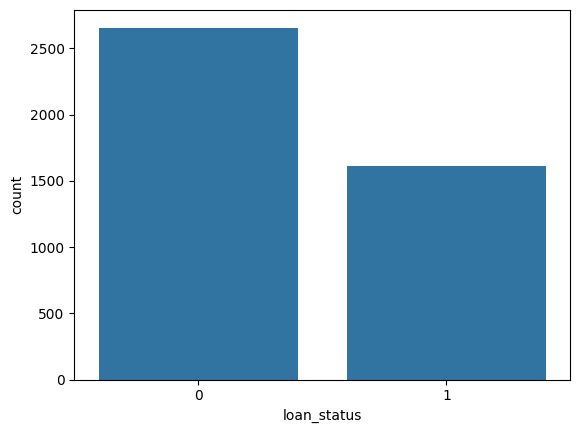

In [82]:
sns.countplot(
    x="loan_status",
    data=df
)

plt.savefig("loan_status_distribution.png")
plt.show()

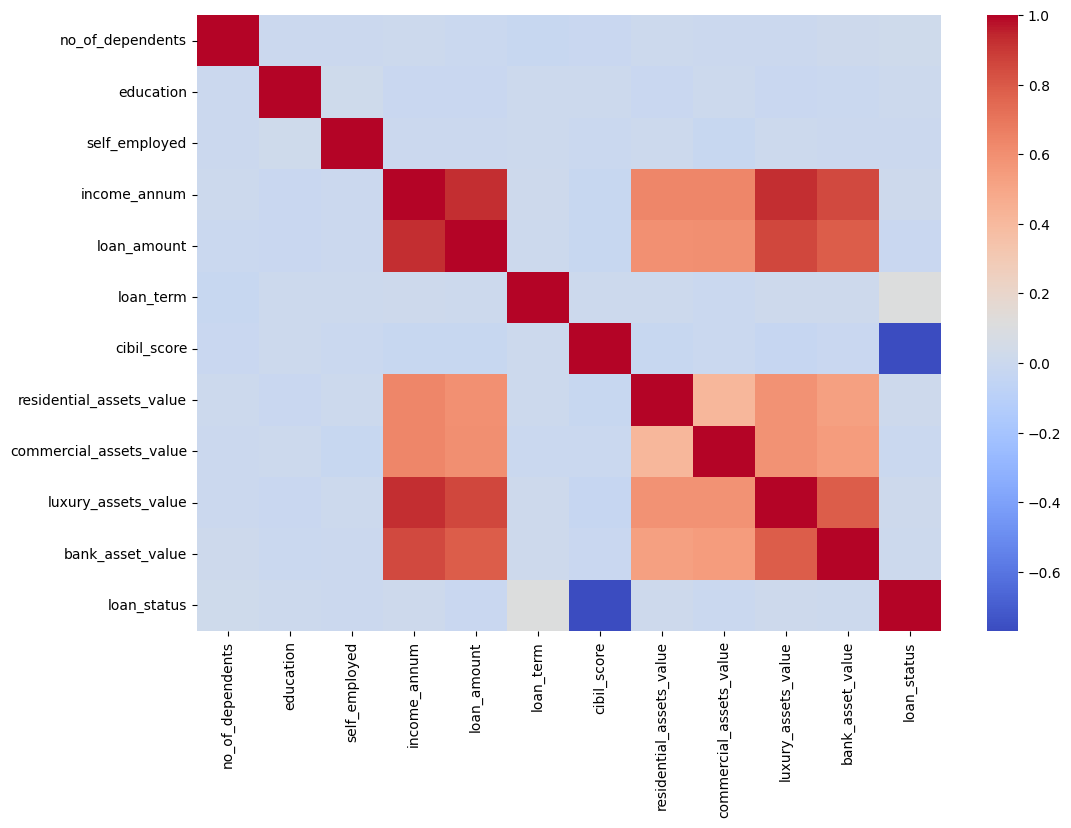

In [83]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.savefig("correlation_heatmap.png")

plt.show()

In [84]:
X = df.drop("loan_status", axis=1)

Y = df["loan_status"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [85]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, Y_train)

lr_prediction = lr.predict(X_test)

In [86]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, Y_train)

dt_prediction = dt.predict(X_test)

In [87]:
print("lr_prediction Accuracy:", accuracy_score(Y_test, lr_prediction))

print("lr_prediction Precision:", precision_score(Y_test, lr_prediction))

print("lr_prediction Recall:", recall_score(Y_test, lr_prediction))

print("lr_prediction F1:", f1_score(Y_test, lr_prediction))

print("lr_prediction classification_report", classification_report(
    Y_test,
    lr_prediction
))

lr_prediction Accuracy: 0.7985948477751756
lr_prediction Precision: 0.8016528925619835
lr_prediction Recall: 0.610062893081761
lr_prediction F1: 0.6928571428571428
lr_prediction classification_report               precision    recall  f1-score   support

           0       0.80      0.91      0.85       536
           1       0.80      0.61      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



In [88]:
print("dt_prediction Accuracy:", accuracy_score(Y_test, dt_prediction))

print("dt_prediction Precision:", precision_score(Y_test, dt_prediction))

print("dt_prediction Recall:", recall_score(Y_test, dt_prediction))

print("dt_prediction F1:", f1_score(Y_test, dt_prediction))

print("dt_prediction classification_report", classification_report(
    Y_test,
    dt_prediction
))

dt_prediction Accuracy: 0.977751756440281
dt_prediction Precision: 0.9716088328075709
dt_prediction Recall: 0.9685534591194969
dt_prediction F1: 0.9700787401574803
dt_prediction classification_report               precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



<Figure size 800x800 with 0 Axes>

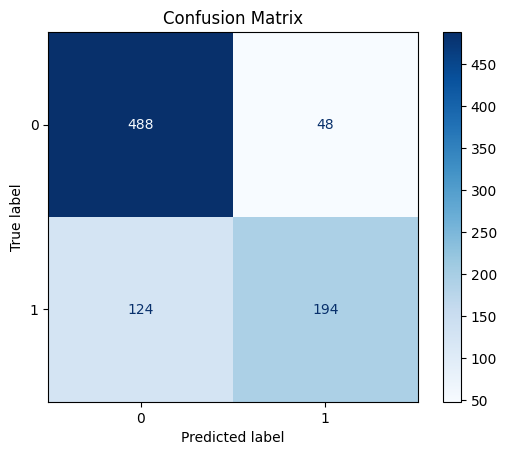

In [90]:
cm = confusion_matrix(
    Y_test,
    lr_prediction
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix_logistic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x800 with 0 Axes>

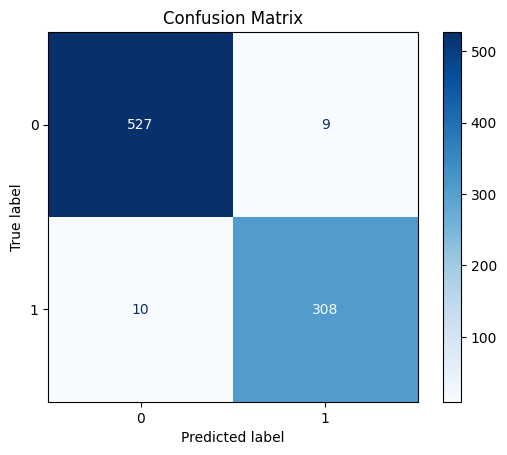

In [91]:
cm = confusion_matrix(
    Y_test,
    dt_prediction
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
!pip install imbalanced-learn

In [93]:
from imblearn.over_sampling import SMOTE

In [94]:
smote = SMOTE(random_state=42)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [95]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_smote, Y_train_smote)
lr_prediction_smote = lr.predict(X_test)

In [96]:
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train_smote, Y_train_smote)
dt_prediction_smote = dt.predict(X_test)

In [97]:
print("lr_prediction_smote Accuracy:", accuracy_score(Y_test, lr_prediction_smote))

print("lr_prediction_smote Precision:", precision_score(Y_test, lr_prediction_smote))

print("lr_prediction_smote Recall:", recall_score(Y_test, lr_prediction_smote))

print("lr_prediction_smote F1:", f1_score(Y_test, lr_prediction_smote))

print("lr_prediction_smote classification_report", classification_report(
    Y_test,
    lr_prediction_smote
))

lr_prediction_smote Accuracy: 0.7845433255269321
lr_prediction_smote Precision: 0.7233333333333334
lr_prediction_smote Recall: 0.6823899371069182
lr_prediction_smote F1: 0.7022653721682848
lr_prediction_smote classification_report               precision    recall  f1-score   support

           0       0.82      0.85      0.83       536
           1       0.72      0.68      0.70       318

    accuracy                           0.78       854
   macro avg       0.77      0.76      0.77       854
weighted avg       0.78      0.78      0.78       854



In [98]:
print("dt_prediction_smote Accuracy:", accuracy_score(Y_test, dt_prediction_smote))

print("dt_prediction_smote Precision:", precision_score(Y_test, dt_prediction_smote))

print("dt_prediction_smote Recall:", recall_score(Y_test, dt_prediction_smote))

print("dt_prediction_smote F1:", f1_score(Y_test, dt_prediction_smote))

print("dt_prediction_smote classification_report", classification_report(
    Y_test,
    dt_prediction_smote
))

dt_prediction_smote Accuracy: 0.9707259953161592
dt_prediction_smote Precision: 0.9592476489028213
dt_prediction_smote Recall: 0.9622641509433962
dt_prediction_smote F1: 0.9607535321821036
dt_prediction_smote classification_report               precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.96      0.96      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [99]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Logistic Regression + SMOTE",
        "Decision Tree + SMOTE"
    ],
    "Accuracy": [
        accuracy_score(Y_test, lr_prediction),
        accuracy_score(Y_test, dt_prediction),
        accuracy_score(Y_test, lr_prediction_smote),
        accuracy_score(Y_test, dt_prediction_smote)
    ],
    "Precision": [
        precision_score(Y_test, lr_prediction),
        precision_score(Y_test, dt_prediction),
        precision_score(Y_test, lr_prediction_smote),
        precision_score(Y_test, dt_prediction_smote)
    ],
    "Recall": [
        recall_score(Y_test, lr_prediction),
        recall_score(Y_test, dt_prediction),
        recall_score(Y_test, lr_prediction_smote),
        recall_score(Y_test, dt_prediction_smote)
    ],
    "F1-Score": [
        f1_score(Y_test, lr_prediction),
        f1_score(Y_test, dt_prediction),
        f1_score(Y_test, lr_prediction_smote),
        f1_score(Y_test, dt_prediction_smote)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.798595,0.801653,0.610063,0.692857
1,Decision Tree,0.977752,0.971609,0.968553,0.970079
2,Logistic Regression + SMOTE,0.784543,0.723333,0.682390,0.702265
3,Decision Tree + SMOTE,0.970726,0.959248,0.962264,0.960754


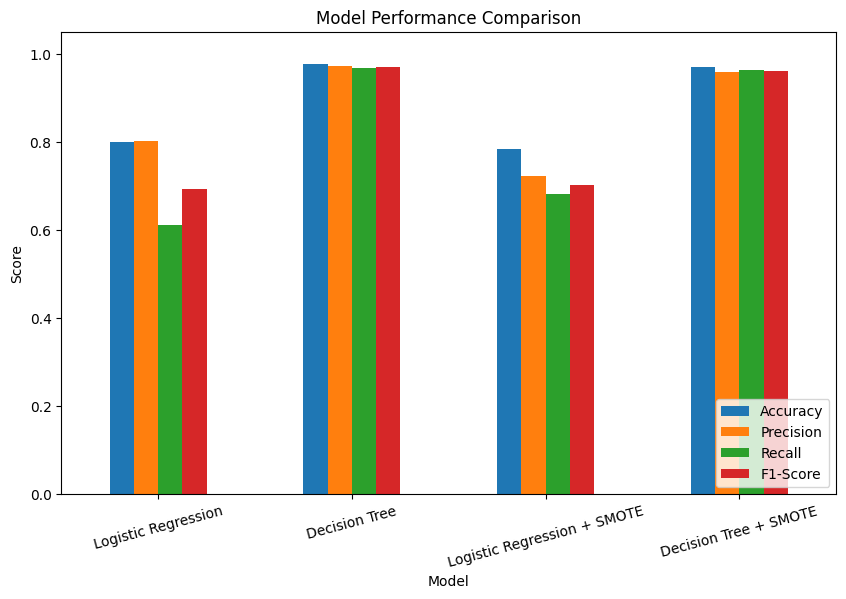

In [100]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()